# <center>Visual Gun Detection System</center>

## 🛠️ Importing Libraries for Visual Gun Detection System

In [1]:
# Import necessary libraries
import cv2
import os
import json
import numpy as np
from glob import glob
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from collections import defaultdict

## 🖼️ Image Preprocessing: Resizing and Filtering

In [2]:
# Set input and output directories
input_dir = "../Data"
output_dir = "../Processing/Preprocessed"
os.makedirs(output_dir, exist_ok=True)

# Get all image paths
image_paths = glob(os.path.join(input_dir, "*.jpg"))

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        continue
    # Resize and apply median filter
    resized = cv2.resize(img, (400, 300))
    filtered = cv2.medianBlur(resized, 3)
    
    # Save processed image
    filename = os.path.basename(img_path)
    cv2.imwrite(os.path.join(output_dir, filename), filtered)

print("Preprocessing complete. Resized and filtered images saved in 'Preprocessed' folder.")

Preprocessing complete. Resized and filtered images saved in 'Preprocessed' folder.


### Visualize Image Preprocessing

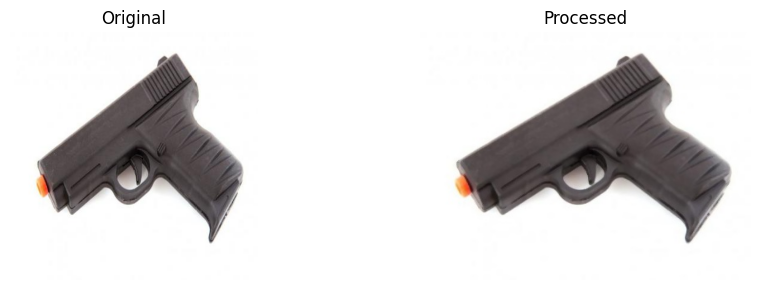

In [3]:
# Choose one image from the input directory
example_filename = os.listdir("../Data")[0]  # or specify a filename manually like "image1.jpg"
original_path = os.path.join("../Data", example_filename)
processed_path = os.path.join("../Processing/Preprocessed", example_filename)

# Load both images
original_img = cv2.imread(original_path)
processed_img = cv2.imread(processed_path)

# Convert BGR (OpenCV) to RGB for matplotlib
original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
processed_img_rgb = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)

# Plot them side by side
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(original_img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_img_rgb)
plt.title("Processed")
plt.axis("off")

plt.tight_layout()
plt.show()


## 🎨 Color Segmentation: K-Means Clustering

In [4]:
# Set directories for input and output
input_dir = "../Processing/Preprocessed"
output_dir = "../Processing/Segmented"
os.makedirs(output_dir, exist_ok=True)

image_paths = glob(os.path.join(input_dir, "*.jpg"))

def segment_image_kmeans(image, k=3):
    # Flatten image and apply KMeans
    Z = image.reshape((-1, 3))
    Z = np.float32(Z)
    kmeans = KMeans(n_clusters=k, n_init=10)
    labels = kmeans.fit_predict(Z)
    centers = np.uint8(kmeans.cluster_centers_)
    
    # Map labels back to image
    segmented = centers[labels].reshape(image.shape)
    labels_img = labels.reshape((image.shape[:2]))
    
    # Create binary mask for dark colors
    brightness = np.sum(centers, axis=1)
    dark_cluster_idx = np.argmin(brightness)
    mask = (labels_img == dark_cluster_idx).astype(np.uint8) * 255
    
    return segmented, mask

for path in image_paths:
    img = cv2.imread(path)
    segmented_img, mask = segment_image_kmeans(img, k=3)
    
    # Save segmented image and mask
    filename = os.path.basename(path)
    cv2.imwrite(os.path.join(output_dir, f"seg_{filename}"), segmented_img)
    cv2.imwrite(os.path.join(output_dir, f"mask_{filename}"), mask)

print("Color segmentation complete. Results saved in 'Segmented' folder.")


Color segmentation complete. Results saved in 'Segmented' folder.


### Visualize Color Segmentation

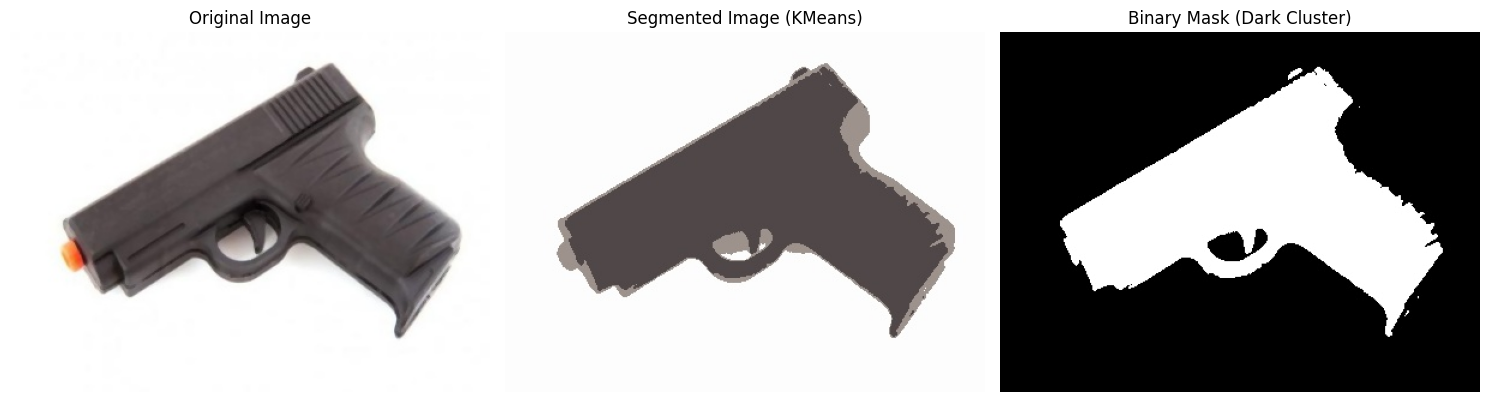

In [5]:
# Define the same directories
input_dir = "../Processing/Preprocessed"
output_dir = "../Processing/Segmented"

# Pick one image to visualize
example_filename = os.listdir(input_dir)[0]  # You can specify one manually if needed
original_path = os.path.join(input_dir, example_filename)
segmented_path = os.path.join(output_dir, f"seg_{example_filename}")
mask_path = os.path.join(output_dir, f"mask_{example_filename}")

# Load images
original = cv2.imread(original_path)
segmented = cv2.imread(segmented_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Convert BGR to RGB for matplotlib
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
segmented_rgb = cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)

# Plot all three
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented_rgb)
plt.title("Segmented Image (KMeans)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask, cmap="gray")
plt.title("Binary Mask (Dark Cluster)")
plt.axis("off")

plt.tight_layout()
plt.show()

## 🧹 Morphological Processing: Closing and Opening

In [6]:
# Set directories for masks and output
input_dir = "../Processing/Segmented"
output_dir = "../Processing/MorphProcessed"
os.makedirs(output_dir, exist_ok=True)

mask_paths = glob(os.path.join(input_dir, "mask_*.jpg"))

for mask_path in mask_paths:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)
    
    # Save processed mask
    filename = os.path.basename(mask_path)
    cv2.imwrite(os.path.join(output_dir, filename), opened)

print("Morphological processing complete. Cleaned masks saved in 'MorphProcessed' folder.")

Morphological processing complete. Cleaned masks saved in 'MorphProcessed' folder.


### Visualize Morphological Processing

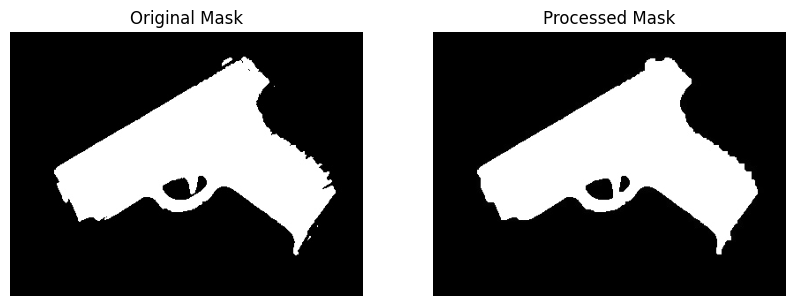

In [7]:
# Set directories
input_dir = "../Processing/Segmented"
output_dir = "../Processing/MorphProcessed"

# Load one original image and its processed version
mask_paths = glob(os.path.join(input_dir, "mask_*.jpg"))
original_mask = cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)
processed_mask = cv2.imread(os.path.join(output_dir, os.path.basename(mask_paths[0])), cv2.IMREAD_GRAYSCALE)

# Plot both the original and processed masks
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_mask, cmap='gray')
plt.title('Original Mask')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(processed_mask, cmap='gray')
plt.title('Processed Mask')
plt.axis('off')

plt.show()

## 🔍 Feature Extraction: Harris, FAST, and FREAK

In [8]:
# Set directories for masks, images, and output
masks_dir = "../Processing/MorphProcessed"
images_dir = "../Processing/Preprocessed"
output_dir = "../Processing/Features"
os.makedirs(output_dir, exist_ok=True)

mask_paths = glob(os.path.join(masks_dir, "*.jpg"))

# Initialize feature detectors
fast = cv2.FastFeatureDetector_create()
freak = cv2.xfeatures2d.FREAK_create()

for mask_path in mask_paths:
    filename = os.path.basename(mask_path).replace("mask_", "")
    image_path = os.path.join(images_dir, filename)
    
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply Harris corner detection
    harris = cv2.cornerHarris(np.float32(mask), 2, 3, 0.04)
    harris = cv2.dilate(harris, None)
    keypoints = np.argwhere(harris > 0.01 * harris.max())
    keypoints = [cv2.KeyPoint(float(x[1]), float(x[0]), 1) for x in keypoints]
    
    # Refine keypoints using FAST
    keypoints = fast.detect(gray, mask)
    
    # Compute FREAK descriptors
    if keypoints:
        keypoints, descriptors = freak.compute(gray, keypoints)
        print(f"{filename}: {len(keypoints)} keypoints")
        
        # Save descriptors and keypoints
        np.save(os.path.join(output_dir, f"{filename}_desc.npy"), descriptors)
        kp_array = np.array([
            (kp.pt[0], kp.pt[1], kp.size, kp.angle, kp.response, kp.octave, kp.class_id)
            for kp in keypoints
        ])
        np.save(os.path.join(output_dir, f"{filename}_kp.npy"), kp_array)
        
        # Visualize and save keypoints
        vis = cv2.drawKeypoints(image, keypoints, None, color=(0,255,0))
        cv2.imwrite(os.path.join(output_dir, f"{filename}_keypoints.jpg"), vis)
    else:
        print(f"{filename}: No keypoints found")

print("Feature extraction complete.")

armas (2162).jpg.rf.a11e4651db00d6d2187bd38e9d110d12.jpg: 222 keypoints
armas (2164).jpg.rf.509331f3bab4d55e30c9424a5d71191e.jpg: 252 keypoints
armas (2166).jpg.rf.cd7e11b851e4f02f8bf1a3391c30530d.jpg: 321 keypoints
armas (2170).jpg.rf.e741e366c59eb75fe0adafcd8d204d79.jpg: 251 keypoints
armas (2172).jpg.rf.cccbf8a463633d9a0cb5242b8471b649.jpg: 233 keypoints
armas (2173).jpg.rf.496fae7144c3c7caae2decbd9e089277.jpg: 289 keypoints
armas (2174).jpg.rf.2b90e506ac2ad566e28c2ca6a095d167.jpg: 147 keypoints
armas (2175).jpg.rf.c5cf55b677b07111b458ae3c0593e177.jpg: 257 keypoints
armas (2176).jpg.rf.2a2d0f7c41146af18614dbe7e5fc0d59.jpg: 227 keypoints
armas (2177).jpg.rf.0db17c3524382149ad01e4e047984f78.jpg: 250 keypoints
armas (2178).jpg.rf.0095da5f53aa7d641eaeafc9c9b9b9ab.jpg: 242 keypoints
armas (2179).jpg.rf.72ef98737738403503dce25b0c4c6129.jpg: 313 keypoints
armas (2180).jpg.rf.01cf6f936229ae6d0a68dec179cf7fde.jpg: 252 keypoints
armas (2181).jpg.rf.22776e9223a74c01a200b37bbcee6755.jpg: 179 ke

### Visualize Feature Extraction

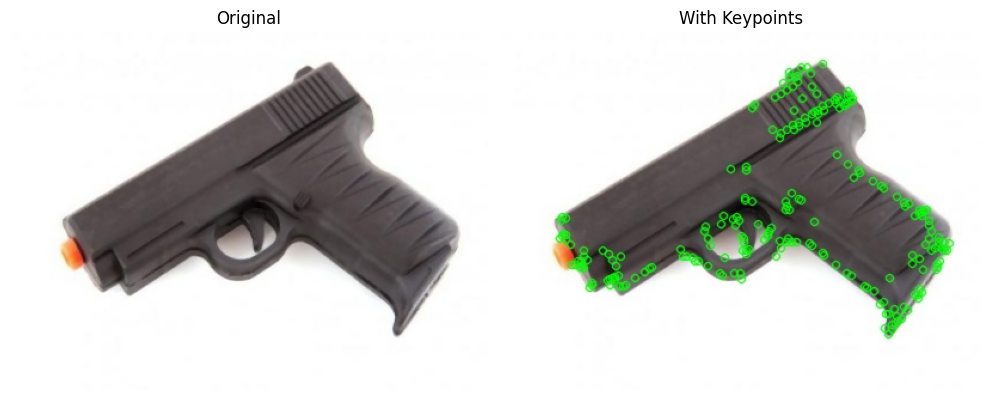

In [9]:
# Choose one image from the output directory
example_filename = os.listdir("../Processing/MorphProcessed")[0]  # or specify a filename manually
image_filename = example_filename.replace("mask_", "")  # Adjust this based on naming convention
original_image_path = os.path.join("../Processing/Preprocessed", image_filename)
keypoints_image_path = os.path.join("../Processing/Features", f"{image_filename}_keypoints.jpg")

# Load both images
original_image = cv2.imread(original_image_path)
keypoints_image = cv2.imread(keypoints_image_path)

# Convert BGR (OpenCV) to RGB for matplotlib
original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
keypoints_image_rgb = cv2.cvtColor(keypoints_image, cv2.COLOR_BGR2RGB)

# Plot them side by side
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(keypoints_image_rgb)
plt.title("With Keypoints")
plt.axis("off")

plt.tight_layout()
plt.show()

## ⚖️ Feature Matching using SSD + Ratio Testing 
### 🔫 Gun Image Feature Extraction: Processing, Segmentation, and Descriptor Matching with Reference Images

In [10]:
# === CONFIGURATION ===
gun_images_dir = '../Processing/Reference'      # Directory containing gun images
output_dir = '../Processing/GunFeatures'        # Directory to save descriptors
resize_dim = (400, 300)                         # Image resizing dimensions
num_clusters = 3                                # Number of KMeans color clusters

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# === Helper Functions ===
def preprocess_image(image):
    # Resize and apply median blur to the image
    image = cv2.resize(image, resize_dim)
    image = cv2.medianBlur(image, 5)
    return image

def color_segmentation(image, k=3):
    # Perform KMeans color segmentation
    img_reshaped = image.reshape((-1, 3))
    img_reshaped = np.float32(img_reshaped)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)
    _, labels, centers = cv2.kmeans(img_reshaped, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    segmented = centers[labels.flatten()]
    segmented_image = segmented.reshape(image.shape).astype(np.uint8)
    return segmented_image

def morphological_process(image):
    # Apply morphological operations to the image
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    result = cv2.bitwise_and(image, image, mask=closed)
    return result

def extract_freak_descriptors(image):
    # Detect Harris corners and compute FREAK descriptors
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    harris_corners = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)
    harris_corners = cv2.dilate(harris_corners, None)
    
    # Collect keypoints from Harris corner locations
    keypoints = []
    for pt in np.argwhere(harris_corners > 0.01 * harris_corners.max()):
        keypoints.append(cv2.KeyPoint(float(pt[1]), float(pt[0]), 1))
    
    if len(keypoints) == 0:
        return None, None

    # Compute FREAK descriptors
    freak = cv2.xfeatures2d.FREAK_create()
    keypoints, descriptors = freak.compute(gray, keypoints)

    return keypoints, descriptors

# === Main Processing ===
image_files = [f for f in os.listdir(gun_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

for image_file in image_files:
    image_path = os.path.join(gun_images_dir, image_file)
    image = cv2.imread(image_path)

    if image is None:
        print(f"Skipping unreadable image: {image_file}")
        continue

    try:
        # Process the image
        preprocessed = preprocess_image(image)
        segmented = color_segmentation(preprocessed, k=num_clusters)
        morphed = morphological_process(segmented)
        kps, desc = extract_freak_descriptors(morphed)

        # Save descriptors if found
        if desc is not None and len(desc) > 0:
            filename_wo_ext = os.path.splitext(image_file)[0]
            np.save(os.path.join(output_dir, f"{filename_wo_ext}_desc.npy"), desc)
            print(f"[✓] Saved features for {image_file}")
        else:
            print(f"[!] No descriptors found for {image_file}")
    except Exception as e:
        print(f"[✗] Error processing {image_file}: {e}")

[✓] Saved features for armas (2260).jpg.rf.0d72501900670609d2a6d8a157afc188.jpg
[✓] Saved features for armas (2264).jpg.rf.15cf647e02e42d5e5fc985244112945c.jpg
[✓] Saved features for armas (2267).jpg.rf.e5dc8999238de9314d9c02e1c3e1a58e.jpg
[✓] Saved features for armas (2268).jpg.rf.23e041ba7492a8e94bb09c05c4e207b4.jpg
[✓] Saved features for armas (2269).jpg.rf.49e942fff3e92d4cda2cd96fe02bed05.jpg
[✓] Saved features for armas (2270).jpg.rf.fcce9334013d36b3b4666ef105d63ed5.jpg
[✓] Saved features for armas (2272).jpg.rf.e25ea4228a99dff6a670684008c43ec8.jpg
[✓] Saved features for armas (2273).jpg.rf.0c222560ad21ff4ec85630a4e86814ae.jpg
[✓] Saved features for armas (2274).jpg.rf.1961a6462f4001697f43dbb51d86bf28.jpg
[✓] Saved features for armas (2275).jpg.rf.59c33f295664a0c399a5742480255bc8.jpg
[✓] Saved features for armas (2276).jpg.rf.762714a376a967516138350cacdebd71.jpg
[✓] Saved features for armas (2277).jpg.rf.bfa9200fa45e63bbe4d72d849a9325ba.jpg
[✓] Saved features for armas (2279).jpg.

### 🕵️ Gun Detection: Descriptor Matching and Classification 

In [11]:
# Directories for feature files
test_desc_dir = "../Processing/Features"          # Current image descriptors
ref_desc_dir = "../Processing/GunFeatures"        # Known gun descriptors
ratio_thresh = 0.7                                # Threshold for descriptor matching

detection_results = {}  # Dictionary to store detection results

def match_descriptors(desc1, desc2, ratio_thresh=0.7):
    # Match descriptors using SSD and ratio test
    matches = []
    for i, d1 in enumerate(desc1):
        ssd = np.sum((desc2 - d1)**2, axis=1)
        if len(ssd) < 2:
            continue
        sorted_indices = np.argsort(ssd)
        best, second_best = ssd[sorted_indices[0]], ssd[sorted_indices[1]]
        if best < ratio_thresh * second_best:
            matches.append(i)
    return matches

# Iterate over test descriptors
for file in os.listdir(test_desc_dir):
    if not file.endswith("_desc.npy"):
        continue

    test_desc = np.load(os.path.join(test_desc_dir, file))
    if test_desc is None or len(test_desc) == 0:
        print(f"{file}: No descriptors found.")
        continue

    total_matches = 0
    # Compare with reference descriptors
    for ref_file in os.listdir(ref_desc_dir):
        if not ref_file.endswith("_desc.npy"):
            continue
        ref_desc = np.load(os.path.join(ref_desc_dir, ref_file))
        if ref_desc is None or len(ref_desc) == 0:
            continue

        matches = match_descriptors(test_desc, ref_desc, ratio_thresh)
        total_matches += len(matches)

    # Decide if the image contains a gun based on matches
    is_gun = total_matches >= 0.5 * len(test_desc)

    print(f"{file}: {'Gun Detected' if is_gun else 'No Gun'} ({total_matches} matches)")

    # Store the result
    image_name = file.replace("_desc.npy", ".jpg")
    detection_results[image_name] = int(is_gun)

# Save the results to a JSON file
with open("../Processing/detection_results.json", "w") as f:
    json.dump(detection_results, f, indent=2)

print("\nDetection results saved to detection_results.json.")

armas (2162).jpg.rf.a11e4651db00d6d2187bd38e9d110d12.jpg_desc.npy: No Gun (99 matches)
armas (2164).jpg.rf.509331f3bab4d55e30c9424a5d71191e.jpg_desc.npy: No Gun (114 matches)
armas (2166).jpg.rf.cd7e11b851e4f02f8bf1a3391c30530d.jpg_desc.npy: Gun Detected (163 matches)
armas (2170).jpg.rf.e741e366c59eb75fe0adafcd8d204d79.jpg_desc.npy: Gun Detected (269 matches)
armas (2172).jpg.rf.cccbf8a463633d9a0cb5242b8471b649.jpg_desc.npy: No Gun (114 matches)
armas (2173).jpg.rf.496fae7144c3c7caae2decbd9e089277.jpg_desc.npy: Gun Detected (190 matches)
armas (2174).jpg.rf.2b90e506ac2ad566e28c2ca6a095d167.jpg_desc.npy: Gun Detected (148 matches)
armas (2175).jpg.rf.c5cf55b677b07111b458ae3c0593e177.jpg_desc.npy: Gun Detected (246 matches)
armas (2176).jpg.rf.2a2d0f7c41146af18614dbe7e5fc0d59.jpg_desc.npy: Gun Detected (155 matches)
armas (2177).jpg.rf.0db17c3524382149ad01e4e047984f78.jpg_desc.npy: Gun Detected (143 matches)
armas (2178).jpg.rf.0095da5f53aa7d641eaeafc9c9b9b9ab.jpg_desc.npy: Gun Detected

## 📊 Ground Truth Extraction: Gun Annotations Mapping

In [44]:
# Load annotation file
with open('../Data/_annotations.coco.json', 'r') as f:
    coco = json.load(f)

# Create a map from image_id to filename
id_to_filename = {img["id"]: img["file_name"] for img in coco["images"]}

# Track which images contain guns
image_has_gun = defaultdict(bool)

for ann in coco["annotations"]:
    image_id = ann["image_id"]
    category_id = ann["category_id"]
    # Category 1 = gun/pistol
    if category_id == 1:
        image_has_gun[image_id] = True

# List the images available in the Data folder
image_files = set(os.listdir('../Data'))  # List of files in the Data folder
image_files = {f.lower() for f in image_files}  # Make file names case-insensitive

# Build the final dictionary, filtering images that exist in the folder
ground_truth = {
    filename: int(image_has_gun[img_id]) 
    for img_id, filename in id_to_filename.items() 
    if filename.lower() in image_files
}

# Save the ground truth to a JSON file
with open("../Processing/ground_truth.json", "w") as f:
    json.dump(ground_truth, f, indent=2)

print(f"Extracted ground truth for {len(ground_truth)} images.")

Extracted ground truth for 15 images.


## 📈 Model Evaluation: Detection Results vs Ground Truth

In [45]:
# Sort detection results and ground truth by filenames
sorted_detection_results = dict(sorted(detection_results.items()))
sorted_ground_truth = dict(sorted(ground_truth.items()))

# Ensure filenames match exactly
sorted_detection_results = {k.replace('.jpg.jpg', '.jpg'): v for k, v in sorted_detection_results.items()}

# Initialize counters for TP, FP, TN, FN
TP = FP = TN = FN = 0

# Evaluate the results
for filename, true_label in sorted_ground_truth.items():
    pred = sorted_detection_results.get(filename, 0)  # Default to 0 if not found
    
    if true_label == 1 and pred == 1:
        TP += 1  # True Positive
    elif true_label == 0 and pred == 1:
        FP += 1  # False Positive
    elif true_label == 0 and pred == 0:
        TN += 1  # True Negative
    elif true_label == 1 and pred == 0:
        FN += 1  # False Negative

# Calculate evaluation metrics
accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
true_positive_rate = TP / (TP + FN) if (TP + FN) > 0 else 0
false_positive_rate = FP / (FP + TN) if (FP + TN) > 0 else 0

# Print the evaluation results
print(f"TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}")
print(f"Accuracy: {accuracy:.2f}")
print(f"True Positive Rate (Recall): {true_positive_rate:.2f}")
print(f"False Positive Rate: {false_positive_rate:.2f}")

TP: 12, FP: 0, TN: 0, FN: 3
Accuracy: 0.80
True Positive Rate (Recall): 0.80
False Positive Rate: 0.00


# 🔍 Feature Detection Comparison: Harris+FREAK vs SIFT vs ORB

### 1️⃣ Harris+FREAK Feature Extraction Pipeline

In [ ]:
harris_freak_features_dir = '../Processing/HarrisFREAK_Features'
os.makedirs(harris_freak_features_dir, exist_ok=True)

reference_dir = '../Processing/Reference'
freak = cv2.xfeatures2d.FREAK_create()

for fname in os.listdir(reference_dir):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_path = os.path.join(reference_dir, fname)
    img = cv2.imread(img_path)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Harris corner detection
    harris = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)
    harris = cv2.dilate(harris, None)
    threshold = 0.001 * harris.max()  # Lower threshold for more keypoints
    keypoints = [cv2.KeyPoint(float(pt[1]), float(pt[0]), 1) for pt in np.argwhere(harris > threshold)]
    if keypoints:
        keypoints, desc = freak.compute(gray, keypoints)
        if desc is not None and len(desc) > 0:
            np.save(os.path.join(harris_freak_features_dir, f'{fname}_desc.npy'), desc)
            vis = cv2.drawKeypoints(img, keypoints, None, color=(0,128,255))
            cv2.imwrite(os.path.join(harris_freak_features_dir, f'{fname}_keypoints.jpg'), vis)
            print(f'Harris+FREAK: Saved descriptors for {fname}')
        else:
            print(f'Harris+FREAK: No descriptors for {fname}')
    else:
        print(f'Harris+FREAK: No keypoints for {fname}')

Harris+FREAK: Saved descriptors for armas (2260).jpg.rf.0d72501900670609d2a6d8a157afc188.jpg
Harris+FREAK: Saved descriptors for armas (2264).jpg.rf.15cf647e02e42d5e5fc985244112945c.jpg
Harris+FREAK: Saved descriptors for armas (2267).jpg.rf.e5dc8999238de9314d9c02e1c3e1a58e.jpg
Harris+FREAK: Saved descriptors for armas (2268).jpg.rf.23e041ba7492a8e94bb09c05c4e207b4.jpg
Harris+FREAK: Saved descriptors for armas (2269).jpg.rf.49e942fff3e92d4cda2cd96fe02bed05.jpg
Harris+FREAK: Saved descriptors for armas (2270).jpg.rf.fcce9334013d36b3b4666ef105d63ed5.jpg
Harris+FREAK: Saved descriptors for armas (2272).jpg.rf.e25ea4228a99dff6a670684008c43ec8.jpg
Harris+FREAK: Saved descriptors for armas (2269).jpg.rf.49e942fff3e92d4cda2cd96fe02bed05.jpg
Harris+FREAK: Saved descriptors for armas (2270).jpg.rf.fcce9334013d36b3b4666ef105d63ed5.jpg
Harris+FREAK: Saved descriptors for armas (2272).jpg.rf.e25ea4228a99dff6a670684008c43ec8.jpg
Harris+FREAK: Saved descriptors for armas (2273).jpg.rf.0c222560ad21ff

### 2️⃣ SIFT Feature Extraction Pipeline

In [ ]:
sift = cv2.SIFT_create()
sift_features_dir = '../Processing/SIFT_Features'
os.makedirs(sift_features_dir, exist_ok=True)

reference_dir = '../Processing/Reference'
for fname in os.listdir(reference_dir):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_path = os.path.join(reference_dir, fname)
    img = cv2.imread(img_path)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kps, desc = sift.detectAndCompute(gray, None)
    if desc is not None and len(desc) > 0:
        np.save(os.path.join(sift_features_dir, f'{fname}_desc.npy'), desc)
        vis = cv2.drawKeypoints(img, kps, None, color=(0,255,0))
        cv2.imwrite(os.path.join(sift_features_dir, f'{fname}_keypoints.jpg'), vis)
        print(f'SIFT: Saved descriptors for {fname}')
    else:
        print(f'SIFT: No descriptors for {fname}')

SIFT: Saved descriptors for armas (2260).jpg.rf.0d72501900670609d2a6d8a157afc188.jpg
SIFT: Saved descriptors for armas (2264).jpg.rf.15cf647e02e42d5e5fc985244112945c.jpg
SIFT: Saved descriptors for armas (2267).jpg.rf.e5dc8999238de9314d9c02e1c3e1a58e.jpg
SIFT: Saved descriptors for armas (2268).jpg.rf.23e041ba7492a8e94bb09c05c4e207b4.jpg
SIFT: Saved descriptors for armas (2269).jpg.rf.49e942fff3e92d4cda2cd96fe02bed05.jpg
SIFT: Saved descriptors for armas (2270).jpg.rf.fcce9334013d36b3b4666ef105d63ed5.jpg
SIFT: Saved descriptors for armas (2272).jpg.rf.e25ea4228a99dff6a670684008c43ec8.jpg
SIFT: Saved descriptors for armas (2273).jpg.rf.0c222560ad21ff4ec85630a4e86814ae.jpg
SIFT: Saved descriptors for armas (2274).jpg.rf.1961a6462f4001697f43dbb51d86bf28.jpg
SIFT: Saved descriptors for armas (2275).jpg.rf.59c33f295664a0c399a5742480255bc8.jpg
SIFT: Saved descriptors for armas (2276).jpg.rf.762714a376a967516138350cacdebd71.jpg
SIFT: Saved descriptors for armas (2277).jpg.rf.bfa9200fa45e63bbe

### 3️⃣ ORB Feature Extraction Pipeline

In [8]:
orb = cv2.ORB_create(nfeatures=500)
orb_features_dir = '../Processing/ORB_Features'
os.makedirs(orb_features_dir, exist_ok=True)

for fname in os.listdir(reference_dir):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_path = os.path.join(reference_dir, fname)
    img = cv2.imread(img_path)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kps, desc = orb.detectAndCompute(gray, None)
    if desc is not None and len(desc) > 0:
        np.save(os.path.join(orb_features_dir, f'{fname}_desc.npy'), desc)
        vis = cv2.drawKeypoints(img, kps, None, color=(255,0,0))
        cv2.imwrite(os.path.join(orb_features_dir, f'{fname}_keypoints.jpg'), vis)
        print(f'ORB: Saved descriptors for {fname}')
    else:
        print(f'ORB: No descriptors for {fname}')

ORB: Saved descriptors for armas (2260).jpg.rf.0d72501900670609d2a6d8a157afc188.jpg
ORB: Saved descriptors for armas (2264).jpg.rf.15cf647e02e42d5e5fc985244112945c.jpg
ORB: Saved descriptors for armas (2267).jpg.rf.e5dc8999238de9314d9c02e1c3e1a58e.jpg
ORB: Saved descriptors for armas (2268).jpg.rf.23e041ba7492a8e94bb09c05c4e207b4.jpg
ORB: Saved descriptors for armas (2269).jpg.rf.49e942fff3e92d4cda2cd96fe02bed05.jpg
ORB: Saved descriptors for armas (2270).jpg.rf.fcce9334013d36b3b4666ef105d63ed5.jpg
ORB: Saved descriptors for armas (2272).jpg.rf.e25ea4228a99dff6a670684008c43ec8.jpg
ORB: Saved descriptors for armas (2273).jpg.rf.0c222560ad21ff4ec85630a4e86814ae.jpg
ORB: Saved descriptors for armas (2274).jpg.rf.1961a6462f4001697f43dbb51d86bf28.jpg
ORB: Saved descriptors for armas (2275).jpg.rf.59c33f295664a0c399a5742480255bc8.jpg
ORB: Saved descriptors for armas (2276).jpg.rf.762714a376a967516138350cacdebd71.jpg
ORB: Saved descriptors for armas (2277).jpg.rf.bfa9200fa45e63bbe4d72d849a932

## 🏎️ Performance Comparison: Harris+FREAK vs SIFT vs ORB

In [ ]:
reference_dir = '../Processing/Reference'

results = []
for fname in os.listdir(reference_dir):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    row = {'image': fname}
    # Harris+FREAK
    freak_path = f"../Processing/HarrisFREAK_Features/{fname}_desc.npy"
    if os.path.exists(freak_path):
        row['Harris+FREAK'] = np.load(freak_path).shape[0]
    else:
        row['Harris+FREAK'] = 0
    # SIFT
    sift_path = f"../Processing/SIFT_Features/{fname}_desc.npy"
    if os.path.exists(sift_path):
        row['SIFT'] = np.load(sift_path).shape[0]
    else:
        row['SIFT'] = 0
    # ORB
    orb_path = f"../Processing/ORB_Features/{fname}_desc.npy"
    if os.path.exists(orb_path):
        row['ORB'] = np.load(orb_path).shape[0]
    else:
        row['ORB'] = 0
    results.append(row)
df = pd.DataFrame(results)
df.head()

,image,Harris+FREAK,SIFT,ORB
0,armas (2260).jpg.rf.0d72501900670609d2a6d8a157...,9644,189,500
1,armas (2264).jpg.rf.15cf647e02e42d5e5fc9852441...,7505,195,479
2,armas (2267).jpg.rf.e5dc8999238de9314d9c02e1c3...,8584,144,443
3,armas (2268).jpg.rf.23e041ba7492a8e94bb09c05c4...,8528,156,456
4,armas (2269).jpg.rf.49e942fff3e92d4cda2cd96fe0...,8967,110,476


### 🔬 Visualize and Compare Harris+FREAK, SIFT, and ORB Keypoints

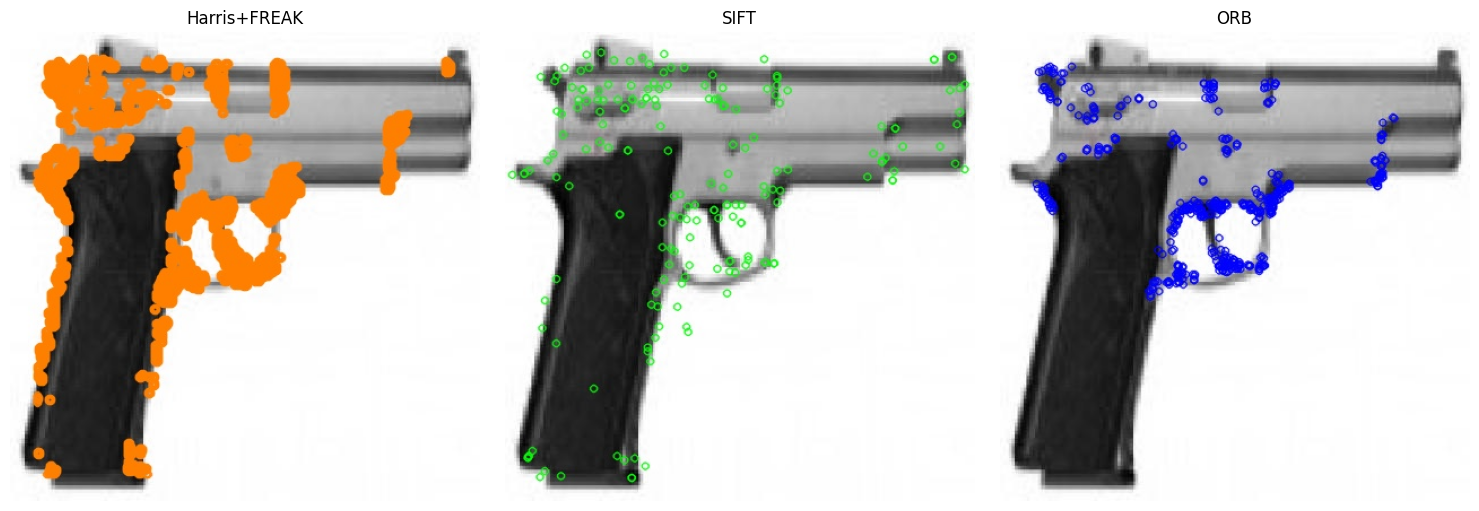

In [ ]:
# Choose an example image filename from your Reference folder
example_fname = os.listdir('../Processing/Reference')[0]

# Paths to keypoint visualization images
harris_path = f"../Processing/HarrisFREAK_Features/{example_fname}_keypoints.jpg"
sift_path = f"../Processing/SIFT_Features/{example_fname}_keypoints.jpg"
orb_path = f"../Processing/ORB_Features/{example_fname}_keypoints.jpg"

# Load images
def load_img(path):
    if os.path.exists(path):
        return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    return None

harris_img = load_img(harris_path)
sift_img = load_img(sift_path)
orb_img = load_img(orb_path)

# Plot side by side
plt.figure(figsize=(15, 5))
if harris_img is not None:
    plt.subplot(1, 3, 1)
    plt.imshow(harris_img)
    plt.title('Harris+FREAK')
    plt.axis('off')
else:
    print('Harris+FREAK keypoints image not found.')
if sift_img is not None:
    plt.subplot(1, 3, 2)
    plt.imshow(sift_img)
    plt.title('SIFT')
    plt.axis('off')
else:
    print('SIFT keypoints image not found.')
if orb_img is not None:
    plt.subplot(1, 3, 3)
    plt.imshow(orb_img)
    plt.title('ORB')
    plt.axis('off')
else:
    print('ORB keypoints image not found.')
plt.tight_layout()
plt.show()